# Installs

In [1]:
!pip install prophet
!pip install yfinance

# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as web
import warnings
from prophet import Prophet
import yfinance as yf

# Link The Latest Dataset


In [3]:
google = yf.Ticker("GOOG")
goog_data = google.history(start="2019-08-09")
goog_data = goog_data.reset_index()
# goog_data = goog_data.rename(columns={"Date": "ds", "Close": "y"}
goog_data["Date"] = goog_data["Date"].dt.tz_localize(None)
goog_data.head(10)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2019-08-09,59.375999,59.667923,58.662933,58.881359,21314000,0.0,0.0
1,2019-08-12,58.445208,58.730197,57.873349,58.222176,20060000,0.0,0.0
2,2019-08-13,58.061091,59.712527,58.061091,59.340309,25888000,0.0,0.0
3,2019-08-14,58.301476,58.598362,57.519869,57.705730,31574000,0.0,0.0
4,2019-08-15,57.666568,58.278176,57.597675,57.852924,24374000,0.0,0.0
5,2019-08-16,58.462061,58.619177,58.078443,58.365414,26266000,0.0,0.0
6,2019-08-19,58.984450,59.822062,58.984450,59.398796,24632000,0.0,0.0
7,2019-08-20,59.240201,59.280348,58.588941,58.617687,18310000,0.0,0.0
8,2019-08-21,59.136117,59.426061,58.852614,59.041946,14814000,0.0,0.0
9,2019-08-22,59.181713,59.377092,58.413984,58.956699,18950000,0.0,0.0


# Data Cleaning

## Check the shape

In [4]:
print(f"Dataset shape: {goog_data.shape}") # Number of rows and columns

Dataset shape: (1724, 8)


## Check the data type (and missing values)

In [5]:
goog_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1724 entries, 0 to 1723
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1724 non-null   datetime64[ns]
 1   Open          1724 non-null   float64       
 2   High          1724 non-null   float64       
 3   Low           1724 non-null   float64       
 4   Close         1724 non-null   float64       
 5   Volume        1724 non-null   int64         
 6   Dividends     1724 non-null   float64       
 7   Stock Splits  1724 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 107.9 KB


## (Re)Check for any missing values

In [6]:
print(f"\nMissing values per column:")
print(goog_data.isnull().sum())


Missing values per column:
Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


## Check for any duplicates

In [7]:
duplicates = goog_data.duplicated(subset=["Date"]).sum()
print(f"\nDuplicate dates: {duplicates}")



Duplicate dates: 0


## Check if ***Date*** column is in order

In [8]:
date_column_sorted = goog_data['Date'].is_monotonic_increasing
print(f"Is the 'Date' column in chronological order?:\n{date_column_sorted}")

Is the 'Date' column in chronological order?:
True


## NO missing values. NO duplicates. Date is in order. No missing/skipped indexes. We're good to go.

## Check date range

In [9]:
print(f"Date range: {goog_data['Date'].min().date()} to {goog_data['Date'].max().date()}")
goog_data.head(5)

Date range: 2019-08-09 to 2026-06-18


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2019-08-09,59.375999,59.667923,58.662933,58.881359,21314000,0.0,0.0
1,2019-08-12,58.445208,58.730197,57.873349,58.222176,20060000,0.0,0.0
2,2019-08-13,58.061091,59.712527,58.061091,59.340309,25888000,0.0,0.0
3,2019-08-14,58.301476,58.598362,57.519869,57.705730,31574000,0.0,0.0
4,2019-08-15,57.666568,58.278176,57.597675,57.852924,24374000,0.0,0.0


# The 2 Experiments - **Feature Engineering** & **Data Splitting** (*for training and testing*)

In [10]:
# Rename Date to "ds", and Close to "y"
goog_data = goog_data.rename(columns={"Date": "ds", "Close": "y"})

## **Experiment 1**: Baseline Model (No Volume data)

In [11]:
# Isolate JUST ds and y columns
goog_data_bm = goog_data[['ds', 'y']]
display(goog_data_bm.head())

,ds,y
0,2019-08-09,58.881359
1,2019-08-12,58.222176
2,2019-08-13,59.340309
3,2019-08-14,57.705730
4,2019-08-15,57.852924


### Holdout Method

In [12]:
# Split data into training and testing
cutoff_bm = goog_data_bm ["ds"].max() - pd.DateOffset(days=365)
train_bm = goog_data_bm [goog_data_bm ["ds"] <= cutoff_bm]
test_bm = goog_data_bm [goog_data_bm ["ds"] > cutoff_bm]

print("Experiment 1 - Baseline Model (No Volume)")
print(f"Training on: {train_bm['ds'].min().date()} to {train_bm['ds'].max().date()}")
print(f"Testing on:  {test_bm['ds'].min().date()} to {test_bm['ds'].max().date()}")
print(f"Train size: {len(train_bm)} days | Test size: {len(test_bm)} days")

Experiment 1 - Baseline Model (No Volume)
Training on: 2019-08-09 to 2025-06-18
Testing on:  2025-06-20 to 2026-06-18
Train size: 1473 days | Test size: 251 days


--- Experiment 1: Baseline Model Accuracy ---
MAE:  $103.40
MAPE: 32.98%
RMSE: $118.76


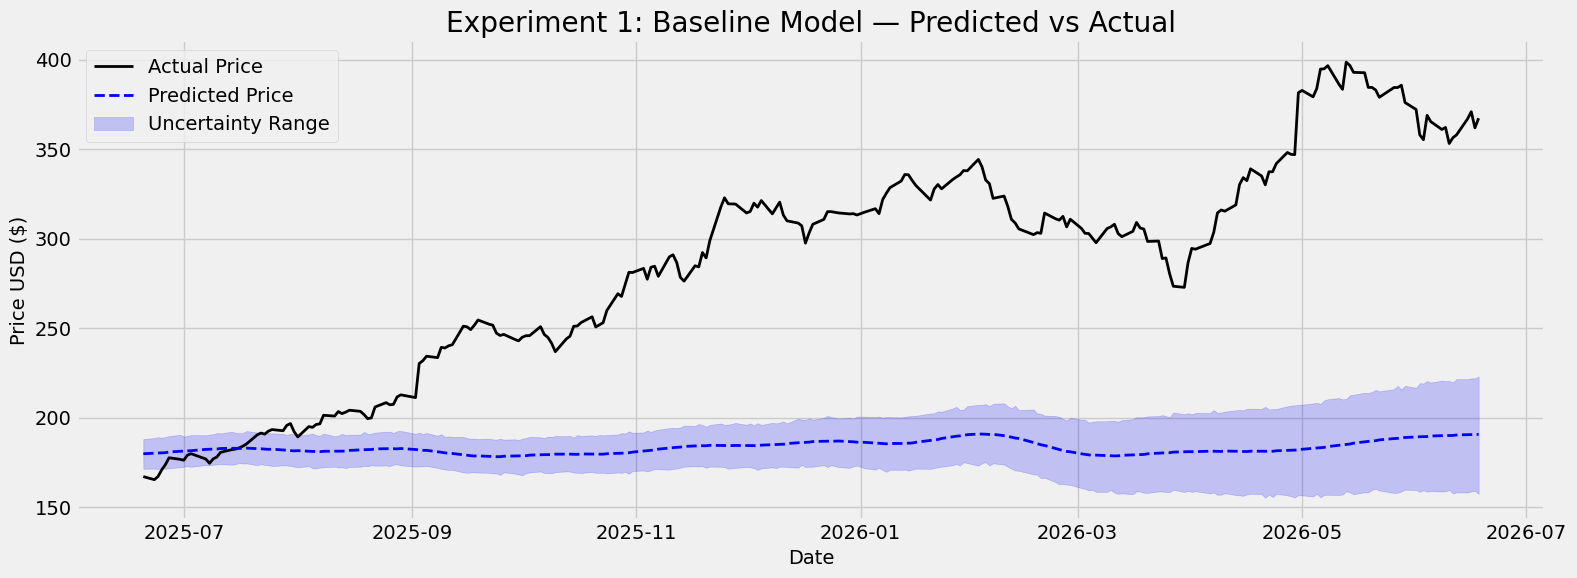

In [13]:
# Train the model on the training portion only
m_bm = Prophet(daily_seasonality=False)
m_bm.fit(train_bm)

# Predict the test period
future_bm = m_bm.make_future_dataframe(periods=365)
forecast_bm = m_bm.predict(future_bm)

# Merge predictions with actual values
forecast_bm = forecast_bm[["ds", "yhat", "yhat_lower", "yhat_upper"]]
results_bm = test_bm.merge(forecast_bm, on="ds")

# Calculate accuracy metrics
mae_bm  = (results_bm["y"] - results_bm["yhat"]).abs().mean()
mape_bm = ((results_bm["y"] - results_bm["yhat"]).abs() / results_bm["y"]).mean() * 100
rmse_bm = ((results_bm["y"] - results_bm["yhat"]) ** 2).mean() ** 0.5

print("--- Experiment 1: Baseline Model Accuracy ---")
print(f"MAE:  ${mae_bm:.2f}")
print(f"MAPE: {mape_bm:.2f}%")
print(f"RMSE: ${rmse_bm:.2f}")

# Plot predicted vs actual
plt.style.use("fivethirtyeight")
plt.figure(figsize=(16, 6))
plt.title("Experiment 1: Baseline Model — Predicted vs Actual")
plt.plot(results_bm["ds"], results_bm["y"],    label="Actual Price",    color="black", linewidth=2)
plt.plot(results_bm["ds"], results_bm["yhat"], label="Predicted Price", color="blue",  linewidth=2, linestyle="--")
plt.fill_between(results_bm["ds"], results_bm["yhat_lower"], results_bm["yhat_upper"], alpha=0.2, color="blue", label="Uncertainty Range")
plt.xlabel("Date", fontsize=14)
plt.ylabel("Price USD ($)", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

## **Experiment 2**: Volume-enhance Model (With Volume data)

In [14]:
# Isolate ds, y, AND Volume columns
goog_data_v = goog_data[['ds', 'y', 'Volume']]
display(goog_data_v.head())

,ds,y,Volume
0,2019-08-09,58.881359,21314000
1,2019-08-12,58.222176,20060000
2,2019-08-13,59.340309,25888000
3,2019-08-14,57.705730,31574000
4,2019-08-15,57.852924,24374000


### Holdout Method

In [15]:
# Split data into training and testing
cutoff_v = goog_data_v["ds"].max() - pd.DateOffset(days=365)
train_v = goog_data_v[goog_data_v["ds"] <= cutoff_v]
test_v  = goog_data_v[goog_data_v["ds"] > cutoff_v]

print("\nExperiment 2 - Volume-enhanced Model")
print(f"Training on: {train_v['ds'].min().date()} to {train_v['ds'].max().date()}")
print(f"Testing on:  {test_v['ds'].min().date()} to {test_v['ds'].max().date()}")
print(f"Train size: {len(train_v)} days | Test size: {len(test_v)} days")


Experiment 2 - Volume-enhanced Model
Training on: 2019-08-09 to 2025-06-18
Testing on:  2025-06-20 to 2026-06-18
Train size: 1473 days | Test size: 251 days


--- Experiment 2: Volume-Enhanced Model Accuracy ---
MAE:  $103.61
MAPE: 33.06%
RMSE: $118.87


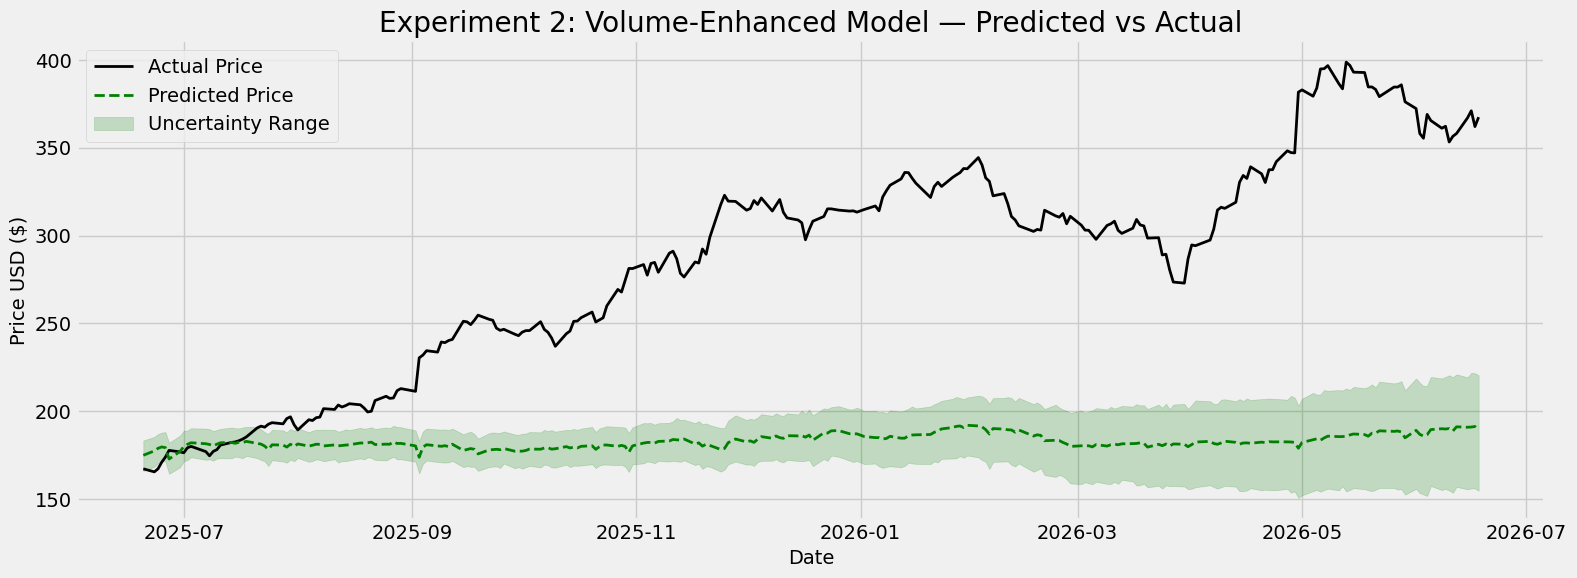

In [16]:
# Train the model on the training portion only, WITH Volume as a regressor
m_v = Prophet(daily_seasonality=False)
m_v.add_regressor("Volume")
m_v.fit(train_v)

# Build the future dataframe
future_v = m_v.make_future_dataframe(periods=365)

# Prophet needs Volume values for the future dates too — not just dates
# Since we don't know future Volume in advance, we estimate it using
# the average Volume from the training data
avg_volume = train_v["Volume"].mean()
future_v = future_v.merge(goog_data_v[["ds", "Volume"]], on="ds", how="left")
future_v["Volume"] = future_v["Volume"].fillna(avg_volume)

# Predict
forecast_v = m_v.predict(future_v)

# Merge predictions with actual values
forecast_v = forecast_v[["ds", "yhat", "yhat_lower", "yhat_upper"]]
results_v = test_v.merge(forecast_v, on="ds")

# Calculate accuracy metrics
mae_v  = (results_v["y"] - results_v["yhat"]).abs().mean()
mape_v = ((results_v["y"] - results_v["yhat"]).abs() / results_v["y"]).mean() * 100
rmse_v = ((results_v["y"] - results_v["yhat"]) ** 2).mean() ** 0.5

print("--- Experiment 2: Volume-Enhanced Model Accuracy ---")
print(f"MAE:  ${mae_v:.2f}")
print(f"MAPE: {mape_v:.2f}%")
print(f"RMSE: ${rmse_v:.2f}")

# Plot predicted vs actual
plt.style.use("fivethirtyeight")
plt.figure(figsize=(16, 6))
plt.title("Experiment 2: Volume-Enhanced Model — Predicted vs Actual")
plt.plot(results_v["ds"], results_v["y"],    label="Actual Price",    color="black", linewidth=2)
plt.plot(results_v["ds"], results_v["yhat"], label="Predicted Price", color="green", linewidth=2, linestyle="--")
plt.fill_between(results_v["ds"], results_v["yhat_lower"], results_v["yhat_upper"], alpha=0.2, color="green", label="Uncertainty Range")
plt.xlabel("Date", fontsize=14)
plt.ylabel("Price USD ($)", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Naive baseline: tomorrow's prediction = today's actual price
test_naive = test_bm.copy()
test_naive["naive_pred"] = test_naive["y"].shift(1)

# Drop the first row since it has no previous day to shift from
test_naive = test_naive.dropna(subset=["naive_pred"])

# Calculate accuracy metrics for the naive model
mae_naive  = (test_naive["y"] - test_naive["naive_pred"]).abs().mean()
mape_naive = ((test_naive["y"] - test_naive["naive_pred"]).abs() / test_naive["y"]).mean() * 100
rmse_naive = ((test_naive["y"] - test_naive["naive_pred"]) ** 2).mean() ** 0.5

print("--- Naive Model Accuracy (Tomorrow = Today) ---")
print(f"MAE:  ${mae_naive:.2f}")
print(f"MAPE: {mape_naive:.2f}%")
print(f"RMSE: ${rmse_naive:.2f}")

--- Naive Model Accuracy (Tomorrow = Today) ---
MAE:  $3.78
MAPE: 1.30%
RMSE: $5.43


## Multi-Horizon

In [18]:
def evaluate_horizon(data, horizon_days, label, use_volume=False):
    cutoff = data["ds"].max() - pd.DateOffset(days=horizon_days)
    train = data[data["ds"] <= cutoff]
    test = data[data["ds"] > cutoff]

    m = Prophet(daily_seasonality=False)

    if use_volume:
        m.add_regressor("Volume")
        m.fit(train)

        future = m.make_future_dataframe(periods=horizon_days)
        avg_volume = train["Volume"].mean()
        future = future.merge(data[["ds", "Volume"]], on="ds", how="left")
        future["Volume"] = future["Volume"].fillna(avg_volume)
    else:
        m.fit(train)
        future = m.make_future_dataframe(periods=horizon_days)

    forecast = m.predict(future)
    forecast = forecast[["ds", "yhat"]]
    results = test.merge(forecast, on="ds")

    mae  = (results["y"] - results["yhat"]).abs().mean()
    mape = ((results["y"] - results["yhat"]).abs() / results["y"]).mean() * 100
    rmse = ((results["y"] - results["yhat"]) ** 2).mean() ** 0.5

    print(f"--- {label} ({horizon_days} days) ---")
    print(f"MAE:  ${mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSE: ${rmse:.2f}\n")

    return {"horizon": horizon_days, "model": label, "mae": mae, "mape": mape, "rmse": rmse}


# Run across multiple horizons, for BOTH versions
results_list = []
for horizon in [7, 30, 90, 180, 365]:
    r1 = evaluate_horizon(goog_data_bm, horizon, "Baseline (no Volume)", use_volume=False)
    r2 = evaluate_horizon(goog_data_v, horizon, "Volume-Enhanced", use_volume=True)
    results_list.append(r1)
    results_list.append(r2)

--- Baseline (no Volume) (7 days) ---
MAE:  $6.96
MAPE: 1.89%
RMSE: $8.18

--- Volume-Enhanced (7 days) ---
MAE:  $6.29
MAPE: 1.71%
RMSE: $7.56

--- Baseline (no Volume) (30 days) ---
MAE:  $22.16
MAPE: 5.91%
RMSE: $25.31

--- Volume-Enhanced (30 days) ---
MAE:  $22.30
MAPE: 5.95%
RMSE: $25.39

--- Baseline (no Volume) (90 days) ---
MAE:  $40.71
MAPE: 11.12%
RMSE: $47.09

--- Volume-Enhanced (90 days) ---
MAE:  $40.18
MAPE: 10.99%
RMSE: $46.44

--- Baseline (no Volume) (180 days) ---
MAE:  $69.34
MAPE: 20.26%
RMSE: $74.04

--- Volume-Enhanced (180 days) ---
MAE:  $68.82
MAPE: 20.10%
RMSE: $73.57

--- Baseline (no Volume) (365 days) ---
MAE:  $103.40
MAPE: 32.98%
RMSE: $118.76

--- Volume-Enhanced (365 days) ---
MAE:  $103.61
MAPE: 33.06%
RMSE: $118.87

